# Time-Series State Estimation and FDI Attacks (IEEE-9)

This notebook generates a labelled cyber–physical time series for a the IEEE-9 bus power system and evaluates the impact of FDI attacks on WLS state estimation.

The workflow is:
1. Generate continuous power-system measurements using pandapower
2. Inject FDI attacks over time
3. Run WLS state estimation at each timestep
4. Analyse residuals and state estimation error

## Inputs

In [18]:
pip install pandapower


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [19]:
pip install seaborn pandas


[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [20]:
import json
import numpy as np
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import matplotlib.pyplot as plt
import pandapower.plotting.plotly as pplot
import seaborn as sns 
import sys
from pathlib import Path
project_root = Path().resolve().parent
sys.path.append(str(project_root))
from src.simulation import load_test_case
from src.time_series import run_time_series
from src.time_series import inject_fdi_time_series
from src.simulation import load_test_case, build_dc_measurement_model, simulate_measurements
import src.state_estimation
from src.state_estimation import wls_estimate, compute_residuals, state_error, run_wls_time_series
from src.attacks import standard_FDIA, random_attack, stealth_FDIA

In [21]:
rng = np.random.default_rng(42)

net = load_test_case("case9")

Z, X_true, converged, H = run_time_series(    
    net,
    T=200,
    p_noise_std=0.01,
    # q_noise_std=0.005,
    meas_noise_std=0.04,
    rng=None,
    seed=42,)

print(Z.shape)       # (200, m)
print(X_true.shape)  # (200, n)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba 

H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba 

H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba 

...

H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
(200, 9)
(200, 8)


In [22]:
print(Z.shape)
print(X_true.shape)

(200, 9)
(200, 8)


In [23]:
# Build H once from the initial operating point
H, _, _, _ = build_dc_measurement_model(net)
Z_att, attack_mask = inject_fdi_time_series(Z, H, attack_type="stealth", rng=rng)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


### Time-Windowed False Data Injection (FDI)

FDI attacks are injected over a fixed time window to emulate realistic attack scenarios.
Outside this window, measurements remain uncompromised.

Three attack types are supported:
- Standard FDI: fixed measurement bias
- Random FDI: stochastic measurement corruption
- Stealth FDI: structured attack aligned with the measurement model


In [24]:
Z_att, mask = inject_fdi_time_series(Z, H, attack_type="stealth", rng=rng)

print(mask.sum())  # should be 100 if start=50, end=150
print(np.linalg.norm(Z_att[100] - Z[100]))  # should be > 0
print(np.linalg.norm(Z_att[10] - Z[10]))    # should be 0


100
0.00042065071379418614
0.0


Attack correctly applied only between t=50 and t=150. No contamination outside the window. Stealth vector is being added correctly.
- Produced a labelled cyber–physical time series:
    - Z(t) → normal measurements
    - Z̃(t) → attacked measurements
    - X_true(t) → physical ground truth
    - attack_mask(t) → exact attack timing


Run WLS at every timestep and compute residual norms over time

In [25]:
sigma = 0.04
r_norms, X_hat = run_wls_time_series(Z_att, H, sigma)

## Residuals over time

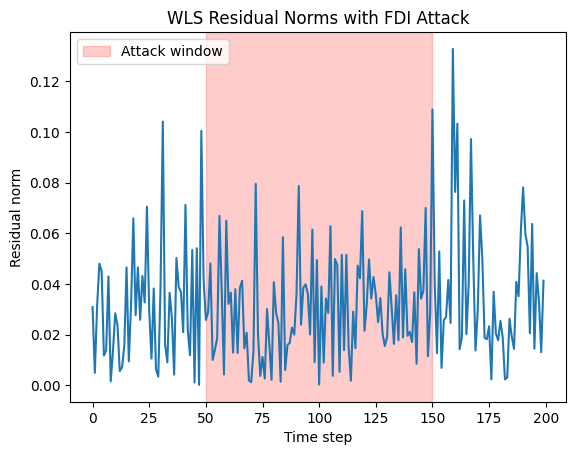

In [26]:
plt.plot(r_norms)
plt.axvspan(50, 150, alpha=0.2, color="red", label="Attack window")
plt.ylabel("Residual norm")
plt.legend()
plt.xlabel("Time step")
plt.title("WLS Residual Norms with FDI Attack")
plt.show()

## State error over time

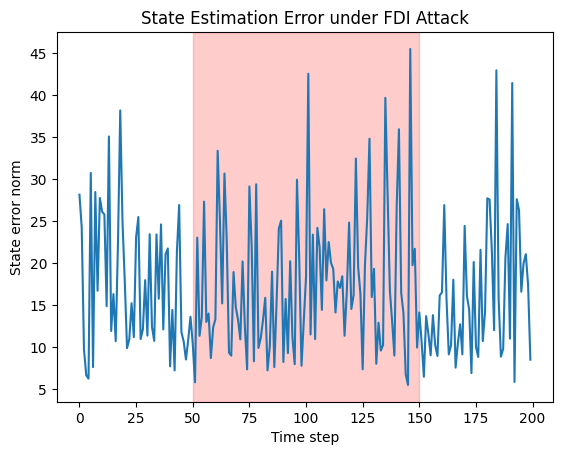

In [27]:
e_norms = np.linalg.norm(X_hat - X_true, axis=1)

plt.plot(e_norms)
plt.axvspan(50, 150, alpha=0.2, color="red")
plt.ylabel("State error norm")
plt.xlabel("Time step")
plt.title("State Estimation Error under FDI Attack")
plt.show()


## Results

- Standard FDI attack
    - Produces increase in WLS residual norms during the attack window.
    - SE error rises sharply at the same time.
    - Confirms that classical residual-based detection is effective for non-stealthy attacks.

- Random FDI attack
    - Residual norms increase noticeably but with higher variability due to the injected noise.
    - SE error rises 
    - Detectable using residual thresholds, though less cleanly than the standard attack.

- Stealth FDI attack
    - Residual norms remain similar to no-attack baseline.
    - SE error increases significantly during the attack window.
    - Demonstrates a weakness of residual-based WLS detection and highlights need for ML-based anomaly detection methods.

## Validation: P-only vs P+Q Load Variability

To validate the impact of reactive power variability, the time-series simulation
was executed under two configurations:

- P-only variation (q_noise_std = 0.0)
- P + Q variation (q_noise_std = 0.005)

Introducing reactive power noise results in increased voltage magnitude diversity
across buses and slightly richer angle dynamics over time, as shown in the plots
below. Importantly, voltage magnitudes remain within realistic operating bounds
and the power flow converges consistently.

This confirms that optional Q variability introduces additional physical realism
without destabilising the system, and is therefore suitable for use as an
enhanced-realism configuration in subsequent ML experiments.


### P only (Active power)

numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


...

H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba 

H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


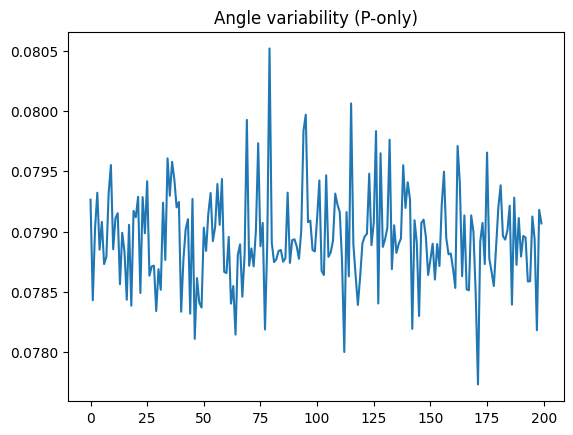

In [ ]:
Z_p, X_p, conv_p, H = run_time_series(
    net,
    p_noise_std=0.01,
    q_noise_std=0.0
)




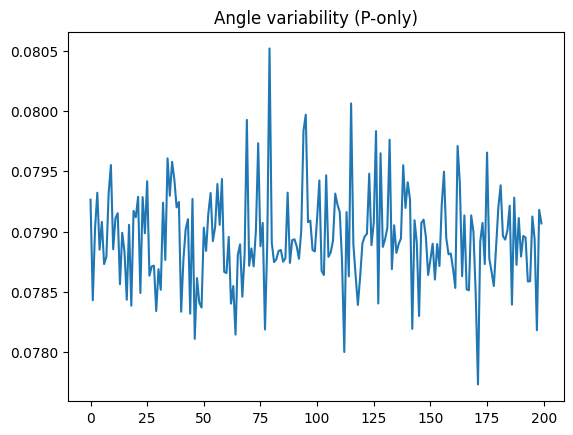

In [34]:
plt.plot(np.std(X_p, axis=1))
plt.title("Angle variability (P-only)")
plt.show()

### P + Q (Active Power - voltage angles + Reactive Power - voltage magnitudes)

In [35]:
Z_pq, X_pq, conv_pq, H = run_time_series(
    net,
    p_noise_std=0.01,
    q_noise_std=0.005
)



numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


...

H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)
numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


numba cannot be imported and numba functions are disabled.
Probably the execution is slow.
Please install numba to gain a massive speedup.
(or if you prefer slow execution, set the flag numba=False to avoid this warning!)


H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)
H shape = (9, 8)
x_true shape = (8,)
z_true shape = (9,)


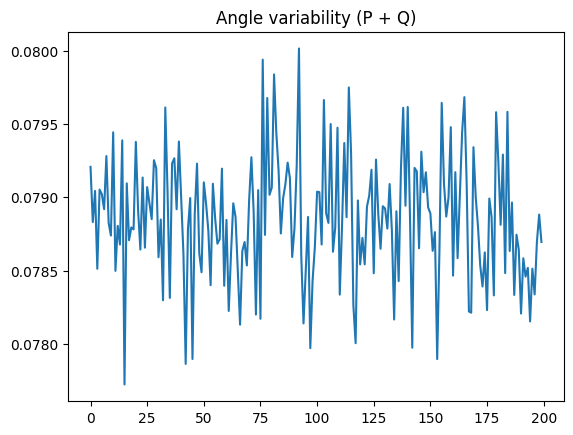

In [36]:
plt.plot(np.std(X_pq, axis=1))
plt.title("Angle variability (P + Q)")
plt.show()

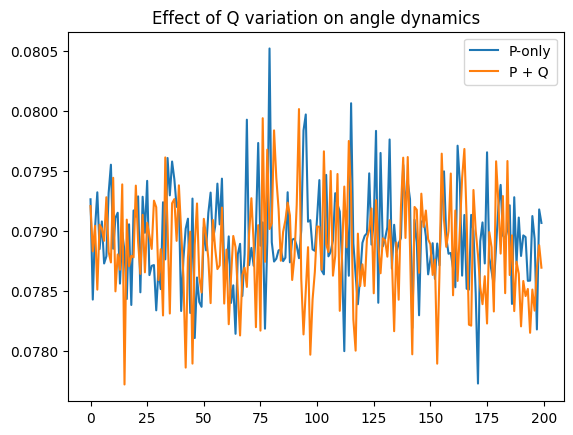

In [37]:
plt.plot(np.std(X_p, axis=1), label="P-only")
plt.plot(np.std(X_pq, axis=1), label="P + Q")
plt.legend()
plt.title("Effect of Q variation on angle dynamics")
plt.show()


## Summary of Results

Active power changes mainly drive how voltage angles vary over time. Adding reactive power variation introduces smaller secondary effects, leading to slightly more varied angle behaviour and greater differences in voltage magnitudes across buses. The P+Q case shows richer system behaviour while remaining stable and within realistic operating limits, indicating that optional Q variation improves physical realism without causing instability.